In [1]:
# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D,Flatten
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn for metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
patient_df = pd.read_csv('./skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

## Checking the Data & Cleaning

In [3]:
patient_df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [4]:
patient_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [5]:
patient_df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [6]:
patient_df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [7]:
patient_df.duplicated().sum()

0

In [8]:
patient_df['age'] = patient_df['age'].fillna(patient_df['age'].mean())

In [9]:
patient_df.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [10]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [11]:
patient_df['cell_type'] = patient_df['dx'].map(lesion_type_dict)
patient_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis-like lesions


In [12]:
patient_df['age'].value_counts()

age
45.000000    1299
50.000000    1187
55.000000    1009
40.000000     985
60.000000     803
70.000000     756
35.000000     753
65.000000     731
75.000000     618
30.000000     464
80.000000     404
85.000000     290
25.000000     247
20.000000     169
5.000000       86
15.000000      77
51.863828      57
10.000000      41
0.000000       39
Name: count, dtype: int64

In [13]:
patient_df = patient_df[patient_df['age']!=0]

In [14]:
patient_df['sex'].value_counts()

sex
male       5383
female     4538
unknown      55
Name: count, dtype: int64

In [15]:
patient_df = patient_df[patient_df['sex']!='unknown']

In [16]:
patient_df['age'].value_counts()

age
45.000000    1297
50.000000    1187
55.000000    1009
40.000000     985
60.000000     800
70.000000     756
35.000000     750
65.000000     731
75.000000     618
30.000000     464
80.000000     404
85.000000     290
25.000000     247
20.000000     169
5.000000       86
15.000000      77
10.000000      41
51.863828      10
Name: count, dtype: int64

In [17]:
patient_df['sex'].value_counts()

sex
male      5383
female    4538
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

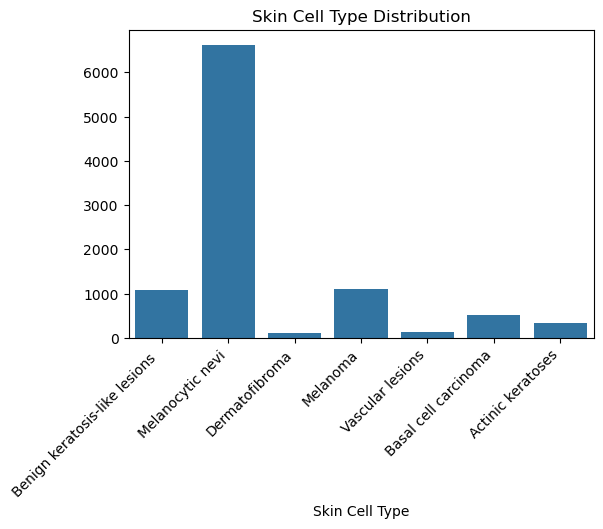

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='cell_type')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Cell Type Distribution')
plt.xlabel('Skin Cell Type')
plt.ylabel('')
plt.show()

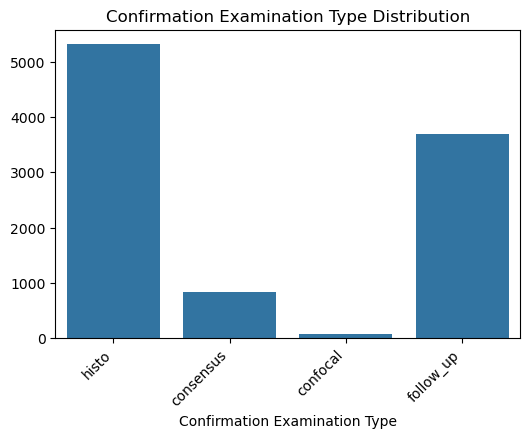

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='dx_type')
plt.xticks(rotation=45,ha='right')
plt.title('Confirmation Examination Type Distribution')
plt.xlabel('Confirmation Examination Type')
plt.ylabel('')
plt.show()

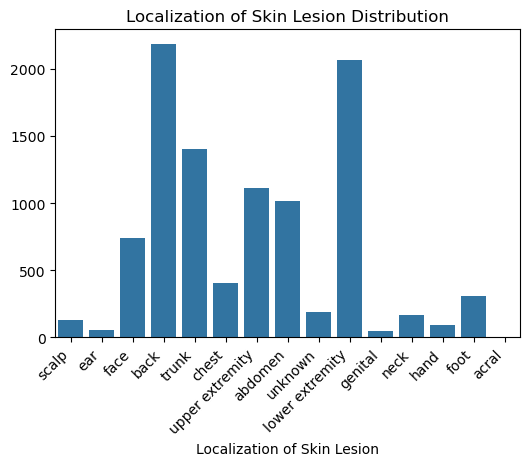

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='localization')
plt.xticks(rotation=45,ha='right')
plt.title('Localization of Skin Lesion Distribution')
plt.xlabel('Localization of Skin Lesion')
plt.ylabel('')
plt.show()

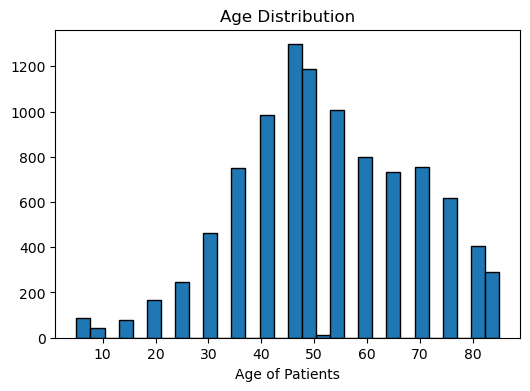

In [21]:
plt.figure(figsize=(6,4))
plt.hist(x=patient_df['age'], bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age of Patients')
plt.ylabel('')
plt.show()

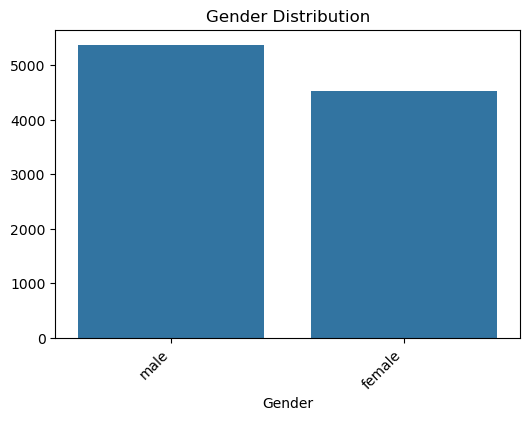

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='sex')
plt.xticks(rotation=45,ha='right')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('')
plt.show()

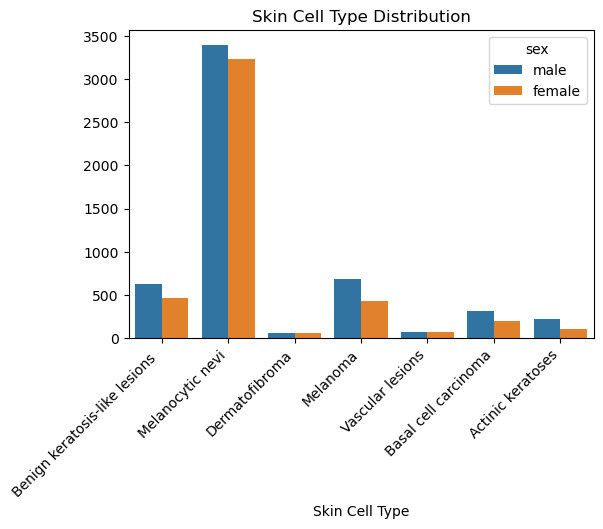

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='cell_type', hue='sex')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Cell Type Distribution')
plt.xlabel('Skin Cell Type')
plt.ylabel('')
plt.show()

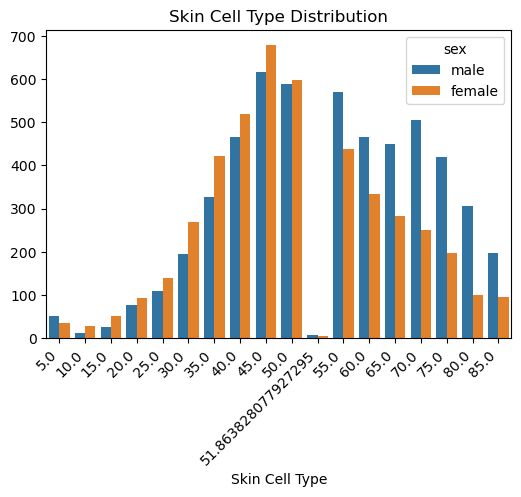

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=patient_df, x='age', hue='sex')
plt.xticks(rotation=45,ha='right')
plt.title('Skin Cell Type Distribution')
plt.xlabel('Skin Cell Type')
plt.ylabel('')
plt.show()

In [25]:
## to make the image id in the dataframe be the same as 
patient_df['image_path'] = patient_df['image_id'].astype(str) + '.jpg'

In [26]:
BASE_DIR = Path('./skin-cancer-mnist-ham10000')  # Update this to your data directory
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
SAMPLE_DIR = BASE_DIR / 'sample'

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
TARGET_SIZE = (IMG_HEIGHT, IMG_WIDTH)

print(f"{TRAIN_DIR}\nTrain directory exists: {TRAIN_DIR.exists()}")
print(f"{TEST_DIR}\nTest directory exists: {TEST_DIR.exists()}")
print(f"{SAMPLE_DIR}\nSample directory exists: {SAMPLE_DIR.exists()}")

skin-cancer-mnist-ham10000\train
Train directory exists: True
skin-cancer-mnist-ham10000\test
Test directory exists: True
skin-cancer-mnist-ham10000\sample
Sample directory exists: True


In [27]:
# Count images in each set
def count_images(directory):
    return len(list(directory.glob('*.jpg')))
    
# Count images in each set
train_total = count_images(TRAIN_DIR)
test_total = count_images(TEST_DIR)

print(f"Training images: {train_total}")
print(f"Test images: {test_total}")

Training images: 8000
Test images: 2015


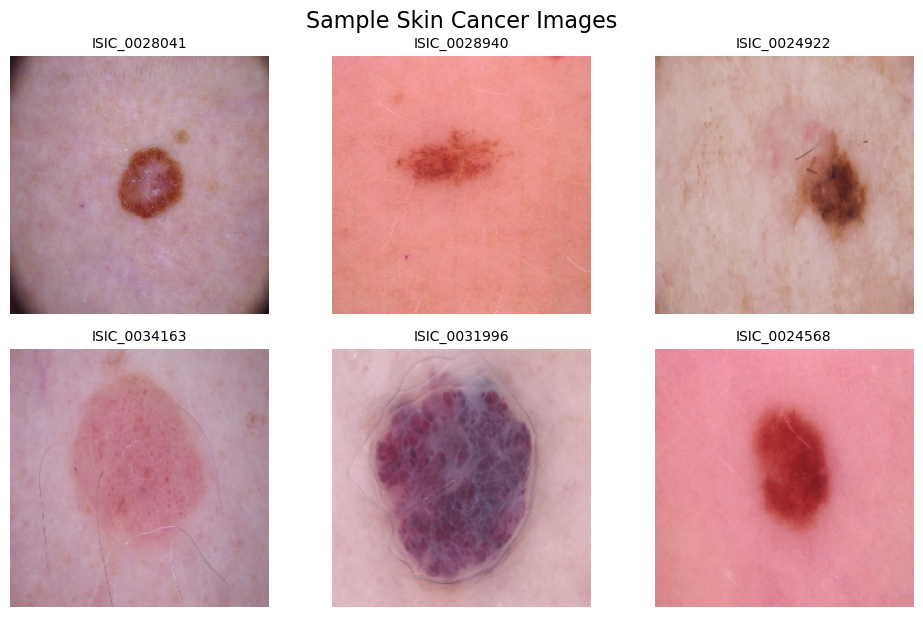

In [28]:
def plot_sample_images(directory, num_samples=12, figsize=(10, 6)):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()
    images = list(directory.glob('*.jpg'))

    for idx in range(0,6):
        if images:
            random_image = np.random.choice(images)
            img = load_img(random_image, target_size=(IMG_HEIGHT, IMG_WIDTH))

            axes[idx].imshow(img)
            axes[idx].set_title(random_image.stem, fontsize=10)
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Sample Skin Cancer Images', fontsize=16, y=1.02)
    plt.show()

plot_sample_images(TRAIN_DIR)

In [29]:
train_data = ImageDataGenerator(
    rescale=1./255, # normalize pixels values to 0-1
    rotation_range=40, # rotating images up 40degress 
    width_shift_range=0.2, # randomly shiftting horizontally by 20%
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

In [30]:
test_data = ImageDataGenerator(
    rescale=1./255
)

In [31]:
train_gen = train_data.flow_from_dataframe(
    dataframe=patient_df,
    directory=TRAIN_DIR,
    x_col='image_path',
    y_col='cell_type',  
    target_size=TARGET_SIZE,
    class_mode='sparse',
    batch_size=BATCH_SIZE
)

test_gen = test_data.flow_from_dataframe(
    dataframe=patient_df,
    directory=TEST_DIR,
    x_col='image_path',
    y_col='cell_type',
    target_size=TARGET_SIZE,
    class_mode='sparse',
    batch_size=BATCH_SIZE
)

Found 7929 validated image filenames belonging to 7 classes.
Found 1992 validated image filenames belonging to 7 classes.


In [32]:
train_gen.class_indices 

{'Actinic keratoses': 0,
 'Basal cell carcinoma': 1,
 'Benign keratosis-like lesions ': 2,
 'Dermatofibroma': 3,
 'Melanocytic nevi': 4,
 'Melanoma': 5,
 'Vascular lesions': 6}

In [33]:
base_model = ResNet50(
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable=False

In [34]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512,activation='relu'),
    Dropout(0.2),
    Dense(512,activation='relu'),
    Dropout(0.2),
    Dense(units=7,activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │           3,591 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,903,047 (95.00 MB)

 Trainable params: 1,315,335 (5.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [35]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [36]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

In [37]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.6688 - loss: 1.1736 - val_accuracy: 0.6581 - val_loss: 1.1415
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - accuracy: 0.6708 - loss: 1.1522 - val_accuracy: 0.6581 - val_loss: 1.1559
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.6708 - loss: 1.1385 - val_accuracy: 0.6581 - val_loss: 1.1352
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 387s 2s/step - accuracy: 0.6708 - loss: 1.1317 - val_accuracy: 0.6581 - val_loss: 1.1185
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.6708 - loss: 1.1296 - val_accuracy: 0.6581 - val_loss: 1.1135
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.6708 - loss: 1.1112 - val_accuracy: 0.6581 - val_loss: 1.0919
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.6708 - loss: 1.1048 - val_accuracy: 0.6581 - val_loss: 1.0894
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.6708 - loss: 1.1204 - val_accu

<Axes: >

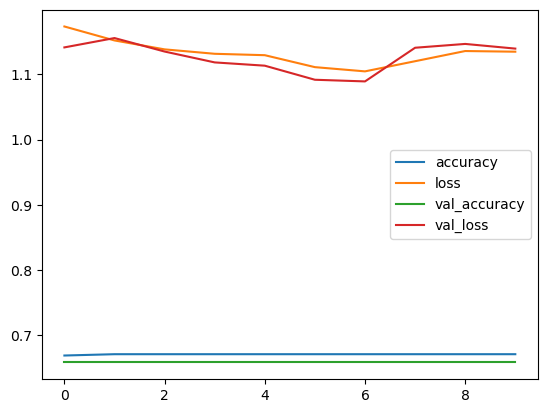

In [38]:
pd.DataFrame(history.history).plot()

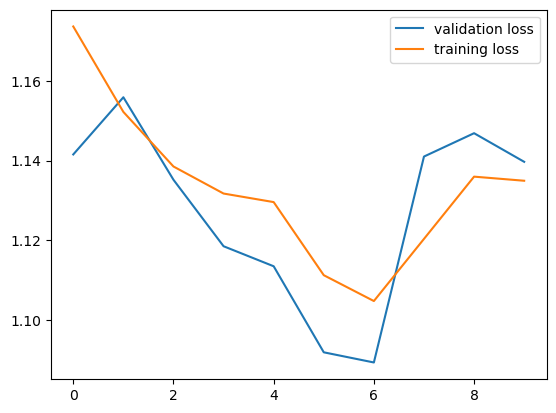

In [39]:
plt.plot(history.history['val_loss'],label='validation loss')
plt.plot(history.history['loss'],label='training loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


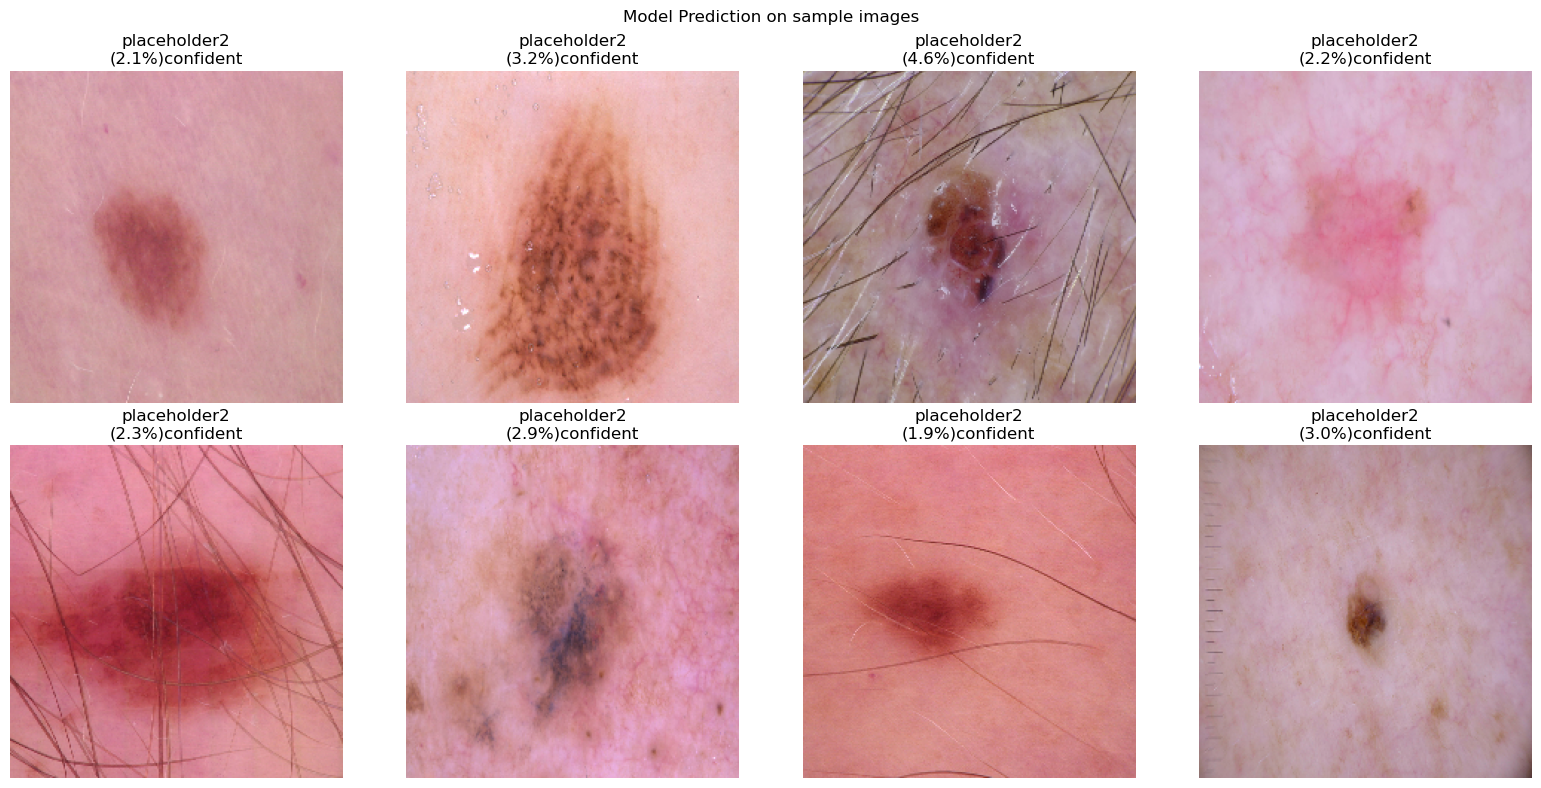

In [40]:
sample_images = [f for f in os.listdir(SAMPLE_DIR) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]

fig, axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images[0:8]): 
    img_path = os.path.join(SAMPLE_DIR, img_name)
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array/255.0

    pred = model.predict(img_array)

    if pred[0][0] > 0.5: 
        label = 'placeholder1'
        conf = pred[0][0]*100
    else: 
        label = 'placeholder2'
        conf = pred[0][0]*100

    axes[i].imshow(img)
    axes[i].set_title(f'{label}\n({conf:.1f}%)confident')
    axes[i].axis('off')
plt.suptitle('Model Prediction on sample images')
plt.tight_layout()
plt.show()